In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NumPy (np)
Used for creating random numbers and numerical data.

Pandas (pd)
Used for working with tables (datasets).

Matplotlib (plt)
Used to create graphs and charts.

In [2]:
np.random.seed(42)

n = 1000

data = {

    "machine_id": np.random.randint(1,50,n),

    "machine_uptime_hours": np.random.normal(20,3,n),

    "downtime_minutes": np.random.randint(5,120,n),

    "production_output_units": np.random.randint(200,500,n),

    "defect_rate_percent": np.random.uniform(0.5,5,n),

    "temperature_celsius": np.random.normal(70,10,n),

    "vibration_level": np.random.uniform(0.1,1.5,n)
}

df = pd.DataFrame(data)

df.head()

,machine_id,machine_uptime_hours,downtime_minutes,production_output_units,defect_rate_percent,temperature_celsius,vibration_level
0,39,20.521899,49,486,1.960303,68.884912,0.865067
1,29,22.723616,104,407,1.712803,61.950335,0.227895
2,15,19.973628,98,313,1.359170,66.123001,1.159305
3,43,21.354234,59,221,3.625884,65.863843,0.915409
4,8,22.447555,117,413,1.484220,65.223544,0.361226


In [3]:
df.describe()

,machine_id,machine_uptime_hours,downtime_minutes,production_output_units,defect_rate_percent,temperature_celsius,vibration_level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25.379000,20.256979,61.357000,344.278000,2.724050,69.304827,0.794330
std,14.122138,3.139907,32.510098,85.250668,1.292480,10.085866,0.407683
min,1.000000,9.945168,5.000000,200.000000,0.500138,39.923677,0.105486
25%,13.000000,18.188241,34.000000,269.000000,1.606294,62.629081,0.434205
50%,26.000000,20.254910,60.000000,340.000000,2.716485,69.398851,0.799711
75%,37.000000,22.371012,90.000000,415.000000,3.821809,75.826129,1.155339
max,49.000000,29.502115,119.000000,499.000000,4.998010,102.430930,1.499245


In [4]:
df["fault_risk"] = np.where(

    (df["temperature_celsius"] > 85) |
    (df["vibration_level"] > 1.2) |
    (df["downtime_minutes"] > 90),

    "High Risk",
    "Normal"
)

df.head()

,machine_id,machine_uptime_hours,downtime_minutes,production_output_units,defect_rate_percent,temperature_celsius,vibration_level,fault_risk
0,39,20.521899,49,486,1.960303,68.884912,0.865067,Normal
1,29,22.723616,104,407,1.712803,61.950335,0.227895,High Risk
2,15,19.973628,98,313,1.359170,66.123001,1.159305,High Risk
3,43,21.354234,59,221,3.625884,65.863843,0.915409,Normal
4,8,22.447555,117,413,1.484220,65.223544,0.361226,High Risk


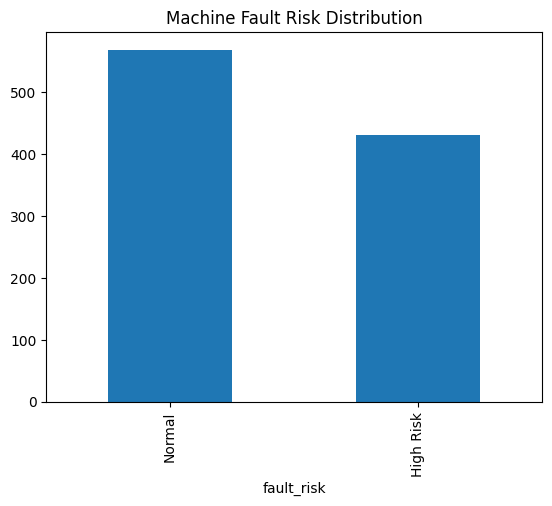

In [5]:
df["fault_risk"].value_counts().plot(kind="bar")

plt.title("Machine Fault Risk Distribution")

plt.show()

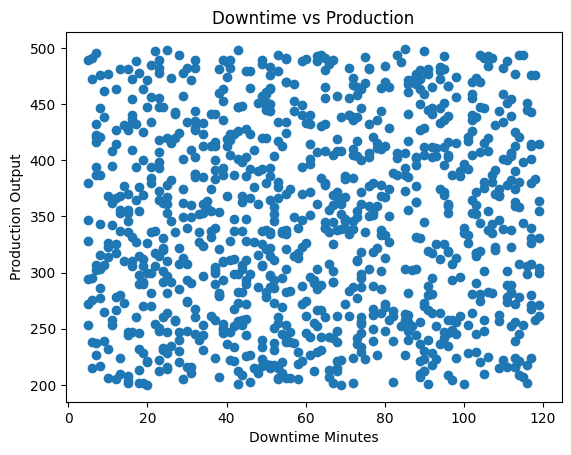

In [6]:
plt.scatter(df["downtime_minutes"], df["production_output_units"])

plt.xlabel("Downtime Minutes")
plt.ylabel("Production Output")

plt.title("Downtime vs Production")

plt.show()

In [7]:
df.to_csv("smart_factory_machine_data.csv", index=False)